# CREMA-D Training Template

A starting point for training an emotion classifier on the CREMA-D spectrogram dataset.

**How to use this template:**
- Run cells from top to bottom.
- Edit the **Configuration** cell to set your batch size, learning rate, image size, and number of epochs.
- Replace the model in the **Model Definition** section with your own architecture.
- Rename this file before you start (e.g. `train_resnet50.ipynb`) so it does not conflict with other team members' notebooks.

**Prerequisites:**
- Python environment active (venv or conda — see `README.md`).
- `data/` folder present in this directory (see `README.md` for the download link).
- Run this notebook from the `training/` directory.

This notebook installs its own Python dependencies via `!pip install` cells — no manual package installation required beyond having Jupyter available.

## 0) Python dependencies

In [52]:
import subprocess, sys

# Core training dependencies
subprocess.check_call([sys.executable, "-m", "pip", "install", "--upgrade", "pip"])
subprocess.check_call([sys.executable, "-m", "pip", "install",
    "torch", "torchvision",
    "matplotlib",
    "scikit-learn",
    "tqdm",
    "numpy",
])

import torch
import torchvision
print(f"torch       {torch.__version__}")
print(f"torchvision {torchvision.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

torch       2.5.1
torchvision 0.20.1
CUDA available: True


## 1) Imports

In [53]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import classification_report, confusion_matrix
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from tqdm import tqdm

## 2) Configuration

Edit the values in this cell to suit your experiment.

In [54]:
# ── Paths ──────────────────────────────────────────────────────────────────
# Assumes this notebook is run from the training/ directory.
# If not, set DATA_DIR manually, e.g.: DATA_DIR = Path("/absolute/path/to/data")
DATA_DIR = Path.cwd() / "data"
TRAIN_DIR = DATA_DIR / "train"
TEST_DIR  = DATA_DIR / "test"

# ── Image settings ─────────────────────────────────────────────────────────
# Spectrograms are 640×640 grayscale PNGs.
# Resize to 224×224 for compatibility with most pretrained backbones.
# Increase if your GPU allows — larger images retain more detail.
IMAGE_SIZE = 224

# ── Training hyperparameters ───────────────────────────────────────────────
BATCH_SIZE    = 16
NUM_EPOCHS    = 75
LEARNING_RATE = 5e-5  # Lower LR for fine-tuning pretrained model and additional layers
NUM_WORKERS   = 0     # Use 0 on Windows to avoid DataLoader worker hangs

# ── Dataset ────────────────────────────────────────────────────────────────
CLASS_NAMES = ["ANG", "DIS", "FEA", "HAP", "NEU", "SAD"]
NUM_CLASSES = len(CLASS_NAMES)

# ── Device ─────────────────────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── Output ─────────────────────────────────────────────────────────────────
MODEL_SAVE_PATH = Path("model_efficientnetb0.pth")

print(f"Data dir : {DATA_DIR}")
print(f"Device   : {DEVICE}")
print(f"Classes  : {CLASS_NAMES}")

Data dir : c:\Users\Jing Rong\Git\ISY-PM-2026-AIS07PT-Group31_PLACEHOLDER\SystemCode\data\training\data
Device   : cuda
Classes  : ['ANG', 'DIS', 'FEA', 'HAP', 'NEU', 'SAD']


## 3) Verify data structure

In [55]:
assert DATA_DIR.exists(), (
    f"data/ not found at {DATA_DIR}.\n"
    "Download it from the shared drive link in training/README.md and extract it here."
)

print(f"{'Split':<8} {'Emotion':<8} {'PNGs':>6} {'WAVs':>6}")
print("-" * 34)
total_png = total_wav = 0
for split, split_dir in [("train", TRAIN_DIR), ("test", TEST_DIR)]:
    for cls in CLASS_NAMES:
        cls_dir = split_dir / cls
        assert cls_dir.exists(), f"Missing expected directory: {cls_dir}"
        n_png = len(list(cls_dir.glob("*.png")))
        n_wav = len(list(cls_dir.glob("*.wav")))
        total_png += n_png
        total_wav += n_wav
        print(f"{split:<8} {cls:<8} {n_png:>6} {n_wav:>6}")

print("-" * 34)
print(f"{'TOTAL':<17} {total_png:>6} {total_wav:>6}")
print("\nData structure OK.")

Split    Emotion    PNGs   WAVs
----------------------------------
train    ANG        1006   1006
train    DIS        1006   1006
train    FEA        1006   1006
train    HAP        1006   1006
train    NEU         860    860
train    SAD        1006   1006
test     ANG         265    265
test     DIS         265    265
test     FEA         265    265
test     HAP         265    265
test     NEU         227    227
test     SAD         265    265
----------------------------------
TOTAL               7442   7442

Data structure OK.


## 4) Dataset and data loaders

`ImageFolder` loads PNGs from subdirectories named by class label — matching exactly how the data is organised.
The spectrograms are grayscale, so we convert to RGB to work with standard 3-channel model architectures.

In [56]:
import torch

class SpecAugment:
    def __init__(self, time_mask=40, freq_mask=30):
        self.time_mask = time_mask
        self.freq_mask = freq_mask

    def __call__(self, spec):
        _, H, W = spec.shape
        # Time mask
        if W > self.time_mask:
            t = torch.randint(0, W - self.time_mask, (1,))
            spec[:, :, t:t+self.time_mask] = 0
        # Frequency mask
        if H > self.freq_mask:
            f = torch.randint(0, H - self.freq_mask, (1,))
            spec[:, f:f+self.freq_mask, :] = 0
        return spec

train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomApply([
        transforms.RandomAffine(degrees=8, translate=(0.08, 0.08), scale=(0.9, 1.1))
    ], p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
    SpecAugment(time_mask=40, freq_mask=30),
])


test_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5]),
])

train_dataset = datasets.ImageFolder(root=str(TRAIN_DIR), transform=train_transforms)
test_dataset  = datasets.ImageFolder(root=str(TEST_DIR),  transform=test_transforms)

from torch.utils.data import WeightedRandomSampler

targets = [label for _, label in train_dataset.samples]
class_sample_counts = np.bincount(targets, minlength=NUM_CLASSES)
weights = 1. / class_sample_counts
sample_weights = [weights[t] for t in targets]

sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=NUM_WORKERS, pin_memory=True)

test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=False)

counts = np.bincount([label for _, label in train_dataset.samples], minlength=NUM_CLASSES)
class_weights = torch.tensor(counts.max() / counts, dtype=torch.float32, device=DEVICE)

print(f"Train samples : {len(train_dataset)}")
print(f"Test  samples : {len(test_dataset)}")
print(f"Class counts : {counts.tolist()}")
print(f"Class mapping : {train_dataset.class_to_idx}")

Train samples : 5890
Test  samples : 1552
Class counts : [1006, 1006, 1006, 1006, 860, 1006]
Class mapping : {'ANG': 0, 'DIS': 1, 'FEA': 2, 'HAP': 3, 'NEU': 4, 'SAD': 5}


### Visualise a batch

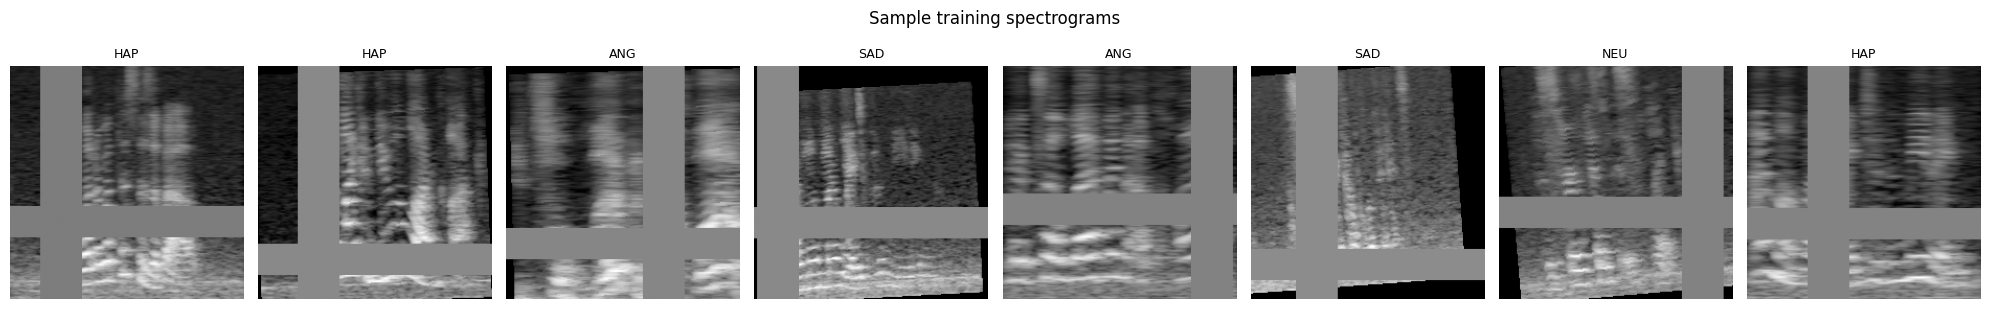

In [57]:
def denorm(tensor):
    """Reverse the 0.5/0.5 normalisation for display."""
    return (tensor * 0.5 + 0.5).clamp(0, 1)

images, labels = next(iter(train_loader))
n_show = min(8, len(images))

fig, axes = plt.subplots(1, n_show, figsize=(2.5 * n_show, 3))
for i, ax in enumerate(axes):
    img = denorm(images[i]).permute(1, 2, 0).numpy()
    ax.imshow(img[:, :, 0], cmap="gray")
    ax.set_title(CLASS_NAMES[labels[i]], fontsize=9)
    ax.axis("off")
plt.suptitle("Sample training spectrograms", y=1.02)
plt.tight_layout()
plt.show()

## 5) Model definition

Using EfficientNet-B0 pretrained on ImageNet for emotion classification.

In [ ]:
import torchvision.models as models

# Load pretrained EfficientNet-B0
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

# Freeze all pretrained layers
for param in model.parameters():
    param.requires_grad = False

# Replace classifier head
model.classifier[1] = nn.Linear(model.classifier[1].in_features, NUM_CLASSES)

# Unfreeze last 3 feature blocks + classifier
for name, param in model.named_parameters():
    if name.startswith("features.5") or name.startswith("features.6") or name.startswith("features.7") or name.startswith("classifier"):
        param.requires_grad = True

model = model.to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params:,}")
print(model)

Trainable parameters: 3,294,414
EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )


In [59]:
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=3e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)



In [60]:
history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

sscaler = torch.cuda.amp.GradScaler()

def run_epoch(loader, training: bool):
    model.train(training)
    total_loss = correct = total = 0
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for images, labels in tqdm(loader, desc="train" if training else "eval ", leave=False):
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            if training:
                optimizer.zero_grad()
                with torch.cuda.amp.autocast():
                    outputs = model(images)
                    loss = criterion(outputs, labels)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                outputs = model(images)
                loss = criterion(outputs, labels)
            total_loss += loss.item() * len(labels)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += len(labels)
    return total_loss / total, correct / total



for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = run_epoch(train_loader, training=True)
    test_loss,  test_acc  = run_epoch(test_loader,  training=False)
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)

    print(f"Epoch {epoch:>3}/{NUM_EPOCHS}  "
          f"train loss {train_loss:.4f}  acc {train_acc:.4f}  "
          f"| test loss {test_loss:.4f}  acc {test_acc:.4f}")

C:\Users\Jing Rong\AppData\Local\Temp\ipykernel_11568\926419695.py:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  sscaler = torch.cuda.amp.GradScaler()
train:   0%|          | 0/369 [00:00<?, ?it/s]

C:\Users\Jing Rong\AppData\Local\Temp\ipykernel_11568\926419695.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch   1/75  train loss 1.4900  acc 0.3929  | test loss 1.4393  acc 0.4581


Epoch   2/75  train loss 1.3261  acc 0.4693  | test loss 1.4522  acc 0.4633


Epoch   3/75  train loss 1.2617  acc 0.4964  | test loss 1.2526  acc 0.5399


...

Epoch  71/75  train loss 0.2633  acc 0.9024  | test loss 1.9805  acc 0.6205


Epoch  72/75  train loss 0.2548  acc 0.9083  | test loss 1.9952  acc 0.6134


Epoch  73/75  train loss 0.2399  acc 0.9132  | test loss 1.9741  acc 0.6147


Epoch  74/75  train loss 0.2532  acc 0.9102  | test loss 1.9985  acc 0.6115


Epoch  75/75  train loss 0.2483  acc 0.9114  | test loss 1.9885  acc 0.6140


### Training curves

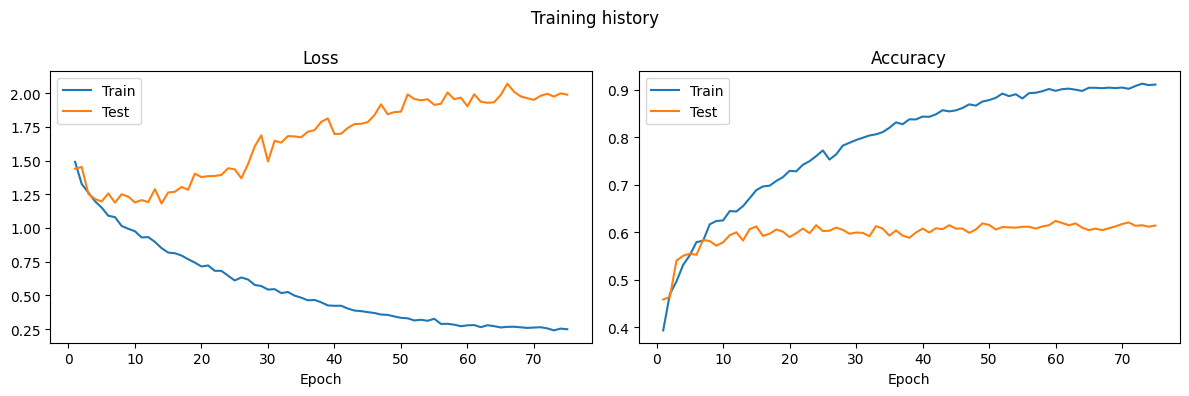

In [61]:
epochs = range(1, NUM_EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs, history["train_loss"], label="Train")
ax1.plot(epochs, history["test_loss"],  label="Test")
ax1.set_title("Loss")
ax1.set_xlabel("Epoch")
ax1.legend()

ax2.plot(epochs, history["train_acc"], label="Train")
ax2.plot(epochs, history["test_acc"],  label="Test")
ax2.set_title("Accuracy")
ax2.set_xlabel("Epoch")
ax2.legend()

plt.suptitle("Training history")
plt.tight_layout()
plt.show()

## 7) Evaluation

In [62]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="evaluating"):
        images = images.to(DEVICE)
        preds  = model(images).argmax(1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

evaluating: 100%|██████████| 97/97 [00:34<00:00,  2.79it/s]

              precision    recall  f1-score   support

         ANG       0.66      0.74      0.70       265
         DIS       0.54      0.55      0.54       265
         FEA       0.54      0.57      0.55       265
         HAP       0.71      0.53      0.60       265
         NEU       0.67      0.75      0.71       227
         SAD       0.58      0.57      0.58       265

    accuracy                           0.61      1552
   macro avg       0.62      0.62      0.61      1552
weighted avg       0.62      0.61      0.61      1552



### Confusion matrix

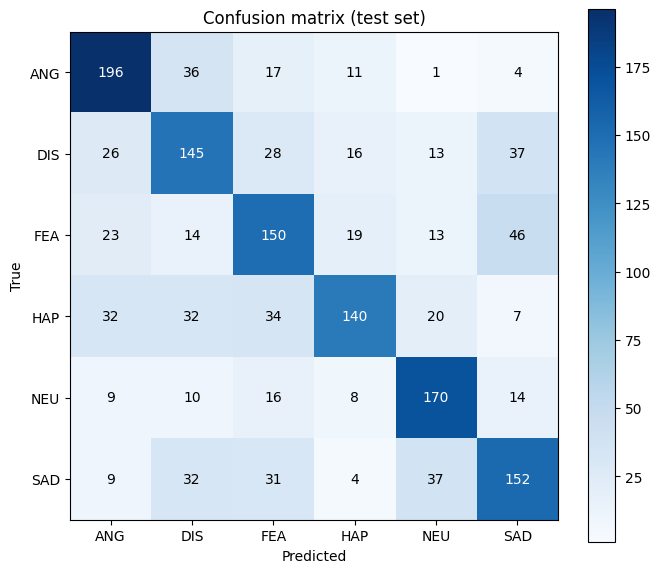

In [63]:
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
plt.colorbar(im, ax=ax)
ax.set_xticks(range(NUM_CLASSES))
ax.set_yticks(range(NUM_CLASSES))
ax.set_xticklabels(CLASS_NAMES)
ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion matrix (test set)")

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")

plt.tight_layout()
plt.show()

## 8) Save the model

In [64]:
torch.save({
    "model_state_dict": model.state_dict(),
    "class_names":      CLASS_NAMES,
    "image_size":       IMAGE_SIZE,
    "num_classes":      NUM_CLASSES,
}, MODEL_SAVE_PATH)

print(f"Model saved to {MODEL_SAVE_PATH.resolve()}")

Model saved to C:\Users\Jing Rong\Git\ISY-PM-2026-AIS07PT-Group31_PLACEHOLDER\SystemCode\data\training\model_efficientnetb0.pth


### Loading the saved model (for inference)

```python
checkpoint = torch.load("model_efficientnetb0.pth", map_location="cpu")
model = models.efficientnet_b0(weights=None)   model.classifier[1] = nn.Linear(model.classifier[1].in_features, checkpoint["num_classes"])
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()
```